In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/kirenz/datasets/master/gapminder.csv"
df = pd.read_csv(url)
df.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


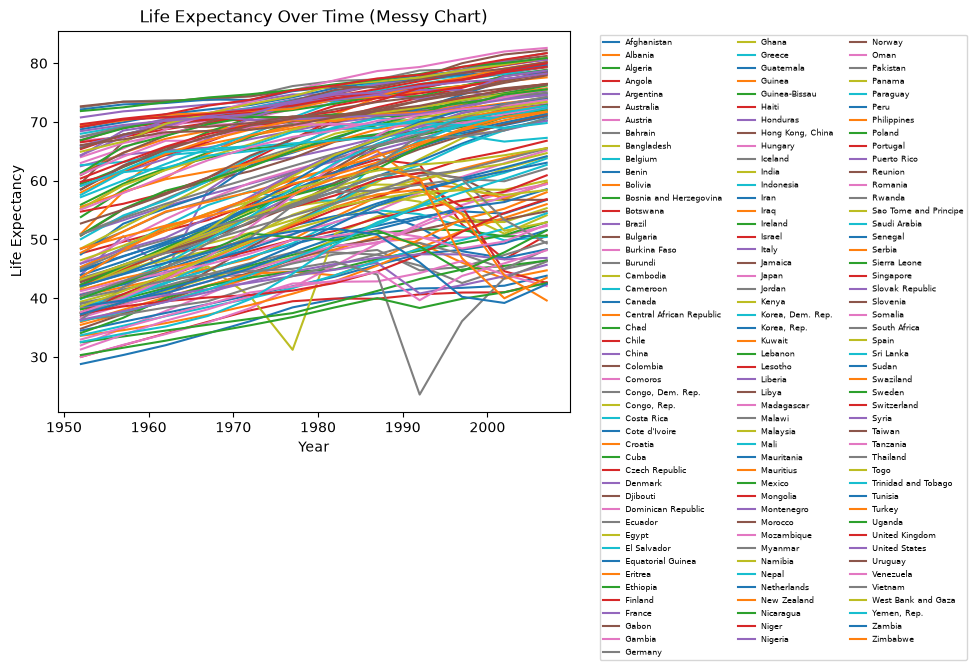

In [3]:
plt.figure(figsize=(10, 6))
for country, group in df.groupby('country'):
    plt.plot(group['year'], group['lifeExp'], label=country)

plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.title('Life Expectancy Over Time (Messy Chart)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small', ncol=3)
plt.tight_layout()
plt.show()

<h4> Plotting all countries on a single chart creates heavy line overlap, making it nearly impossible to track individual country progress or identify which nations are improving versus declining over time. </h4>

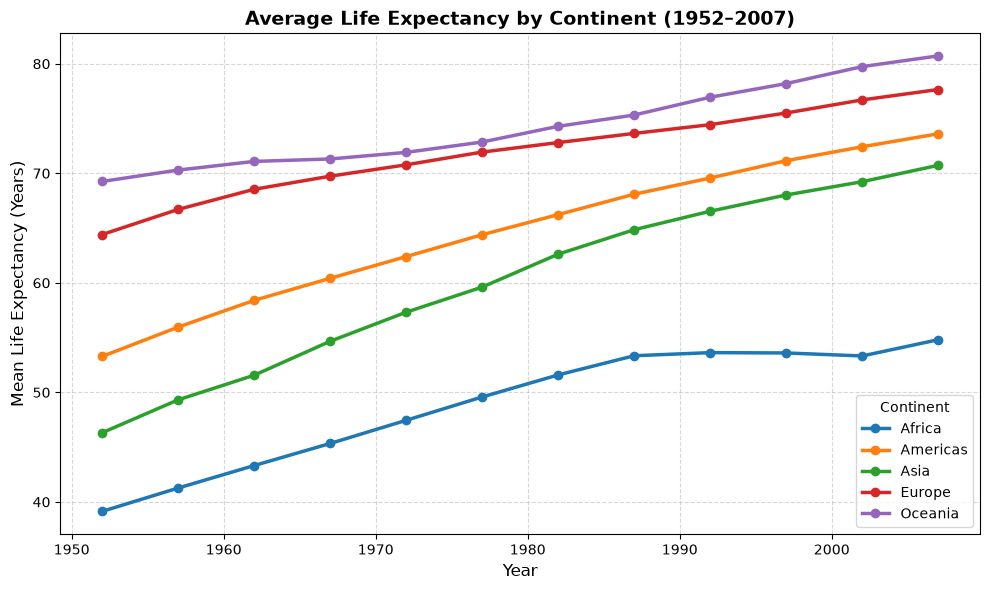

In [4]:
df_continent = df.groupby(['continent', 'year'])['lifeExp'].mean().reset_index()

# Plot aggregated lines
plt.figure(figsize=(10, 6))

for continent, group in df_continent.groupby('continent'):
    plt.plot(group['year'], group['lifeExp'], marker='o', linewidth=2.5, label=continent)

plt.title('Average Life Expectancy by Continent (1952–2007)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Life Expectancy (Years)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Continent', frameon=True)
plt.tight_layout()
plt.show()

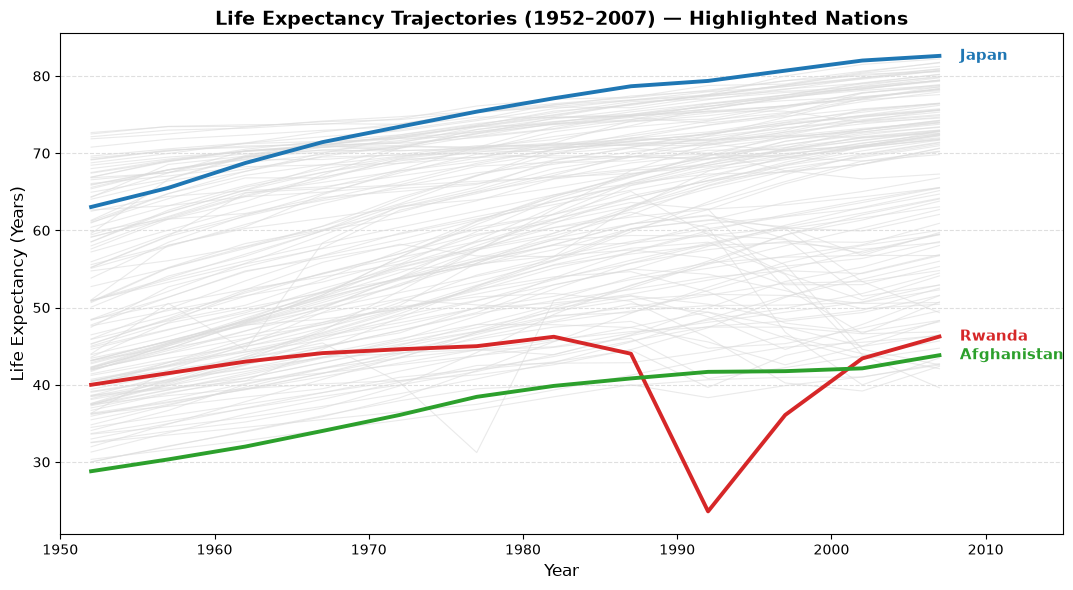

In [5]:
highlight_countries = {
    'Japan': '#1f77b4',     
    'Rwanda': '#d62728',    
    'Afghanistan': '#2ca02c' 
}

fig, ax = plt.subplots(figsize=(11, 6))

for country, group in df.groupby('country'):
    if country not in highlight_countries:
        ax.plot(group['year'], group['lifeExp'], color='gainsboro', alpha=0.6, linewidth=0.8)

for country, color in highlight_countries.items():
    group = df[df['country'] == country]
    ax.plot(group['year'], group['lifeExp'], color=color, linewidth=2.8, label=country)
    
    last_row = group.iloc[-1]
    ax.text(
        last_row['year'] + 1, last_row['lifeExp'], f" {country}",
        color=color, fontweight='bold', va='center', fontsize=11
    )

ax.set_title('Life Expectancy Trajectories (1952–2007) — Highlighted Nations', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Life Expectancy (Years)', fontsize=12)
ax.set_xlim(1950, 2015)  
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

<h4> Option (a) clearly demonstrates the steady upward trend in average life expectancy per continent over time. However, it conceals country-level health crises—spikes and drops that are easily visible in Option (b) when focusing on specific nations. </h4>

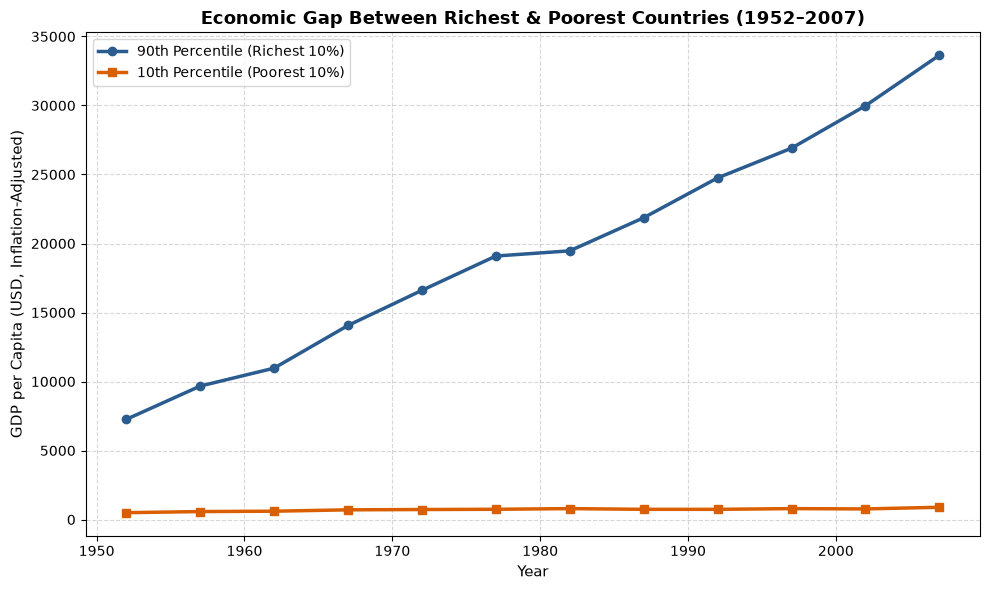

In [7]:

# Calculate 10th and 90th percentiles of GDP per capita for each year
stats = df.groupby('year')['gdpPercap'].agg(
    p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90)
    # REMOVED: median='median'
).reset_index()

# Create a single chart layout (REMOVED: fig, (ax1, ax2) subplot structure)
plt.figure(figsize=(10, 6))

# Plot only Richest 10% and Poorest 10%
plt.plot(stats['year'], stats['p90'], marker='o', color='#2b5c8f', linewidth=2.5, label='90th Percentile (Richest 10%)')
plt.plot(stats['year'], stats['p10'], marker='s', color='#d95f02', linewidth=2.5, label='10th Percentile (Poorest 10%)')
# REMOVED: plt.plot(stats['year'], stats['median'], ...)

# Formatting
plt.title('Economic Gap Between Richest & Poorest Countries (1952–2007)', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('GDP per Capita (USD, Inflation-Adjusted)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

<h4> I selected this chart because it clearly illustrates the widening economic gap between rich and poor nations over time. Rather than plotting individual countries, I grouped the top 10% richest and poorest nations (approximately 14 countries per group) for each year and aggregated their values separately. Using a 10% threshold ensures that the impact of outliers like a poor nation getting a short-term wealth boost from resource discovery (i.e oil) will be reduced. </h4>

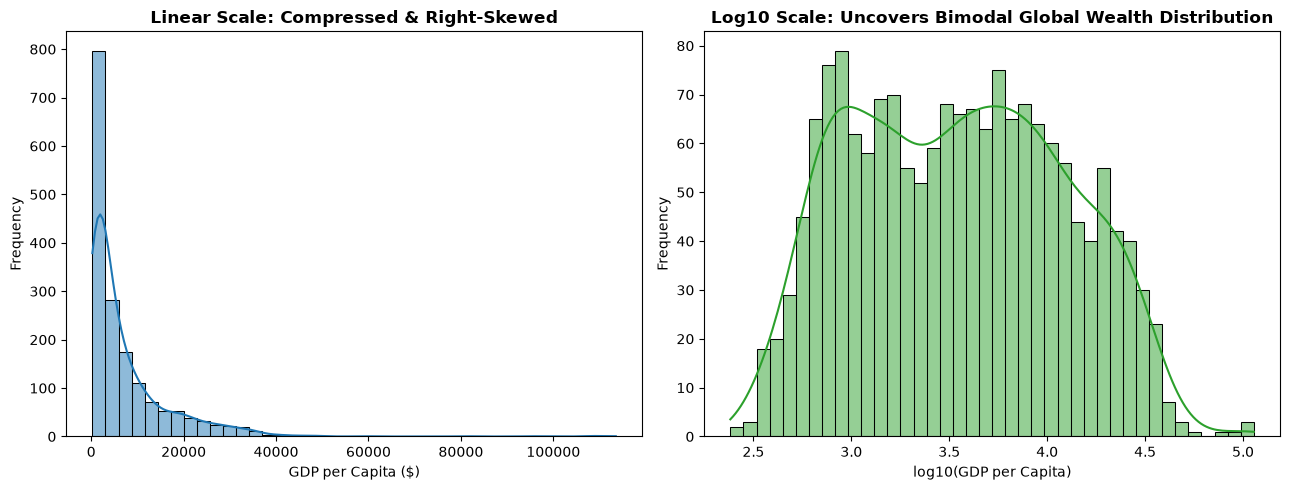

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Linear Scale Histogram
sns.histplot(df['gdpPercap'], bins=40, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Linear Scale: Compressed & Right-Skewed', fontweight='bold')
axes[0].set_xlabel('GDP per Capita ($)')
axes[0].set_ylabel('Frequency')

# 2. Log10 Scale Histogram
sns.histplot(np.log10(df['gdpPercap']), bins=40, kde=True, ax=axes[1], color='#2ca02c')
axes[1].set_title('Log10 Scale: Uncovers Bimodal Global Wealth Distribution', fontweight='bold')
axes[1].set_xlabel('log10(GDP per Capita)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<h4> Log transformation reshapes heavily skewed data into a distribution that is close to normal distribution and because of it the impact of outliers are also reduced. Moreover, using this log transformed chart over the skewed one will help to spot clusters or groups which are being formed in the data </h4>